# Exploratory Data Analysis (EDA) on Road Accidents on State Highways in India (2018–2021)

### Problem Statement

Road traffic accidents remain a significant public health and safety concern in India, contributing to substantial loss of life, injuries, and economic costs annually. Despite efforts to improve road safety, the lack of comprehensive, data-driven insights into accident patterns hinders effective policy-making and resource allocation. The available dataset provides total road accident counts on state highways across Indian states and Union Territories (UTs) from 2018 to 2021. However, without a systematic analysis, it is challenging to identify trends, high-risk regions, and potential factors influencing these accidents. This project aims to address this gap by analyzing the frequency and distribution of road accidents on state highways, providing actionable insights to enhance road safety measures.

### Goals

The primary goals of this project are:

- To analyze the temporal trends in road accident frequency on state highways from 2018 to 2021.
- To identify high-risk states and UTs based on accident counts and rankings in 2021.
- To examine regional variations in accident occurrences across India.
- To visualize key findings using appropriate graphical representations for better interpretability.

### Expected Outcomes

This project will deliver:

- A clear understanding of how road accident frequencies on state highways have evolved over the four-year period (2018–2021).
- Identification of states/UTs with consistently high accident counts, enabling targeted safety interventions.
- Visualizations (e.g., bar charts, line plots, and geospatial maps) to highlight trends and high-risk areas.
- Data-driven insights to inform policymakers and road safety authorities about priority regions and potential focus areas for accident prevention, despite the absence of causal factors in the dataset.

### Dataset Overview

**Source**

The dataset is derived from the "Road Accidents in India" reports published by the Ministry of Road Transport and Highways, available on the Open Government Data (OGD) Platform India (data.gov.in).

### Dataset Description

The dataset contains the following columns:

- 1. States/UTs: Names of Indian states and Union Territories (37 unique entries).
- 2. Total Number of Road Accidents on State Highways during 2018: Accident counts for 2018.
- 3. Total Number of Road Accidents on State Highways during 2019: Accident counts for 2019.
- 4. Total Number of Road Accidents on State Highways during 2020: Accident counts for 2020.
- 5. Total Number of Road Accidents on State Highways during 2021 - Number: Accident counts for 2021.
- 6. Total Number of Road Accidents on State Highways during 2021 - Rank: Ranking of states/UTs based on 2021 accident counts (1 being the highest).

### Scope and Limitations

- **Scope:** The data covers only accidents on state highways, not national highways or other roads, and spans 2018–2021.

- **Limitations:** It lacks granularity (e.g., no monthly/daily data, severity, causes, weather, or vehicle details), restricting the analysis to frequency and regional patterns.

## Methodology

#### Step 1: Data Preprocessing

We’ll load the data, handle "NA" values, address potential inconsistencies (e.g., zeros in states with no state highways), and rename columns for simplicity.

In [1]:
import pandas as pd
import numpy as np

# Loading the dataset
data = {
    'States/UTs': ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttarakhand', 'Uttar Pradesh', 'West Bengal', 'Andaman and Nicobar Islands', 'Chandigarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Jammu and Kashmir', 'Ladakh', 'Lakshadweep', 'Puducherry'],
    '2018': [6398, 94, 2111, 2089, 3136, 331, 4952, 3226, 650, 1686, 10685, 7552, 13910, 7755, 206, 9, 13, 111, 3104, 1876, 3504, 84, 22849, 3521, 186, 342, 13788, 2468, 101, 0, 33, 0, 0, 664, 'NA', 0, 136],
    '2019': [5288, 90, 2102, 1945, 3010, 423, 4558, 2306, 578, 1458, 10446, 8097, 13166, 7214, 203, 50, 36, 69, 3195, 1815, 3824, 47, 19279, 2501, 213, 342, 13402, 2403, 68, 0, 35, 1, 0, 610, 'NA', 0, 202],
    '2020': [4508, 39, 1752, 1711, 2171, 328, 3647, 1872, 423, 1322, 9465, 5876, 11751, 5518, 106, 21, 27, 116, 2365, 1483, 3257, 47, 17213, 1992, 174, 220, 10555, 1975, 34, 0, 33, 'NA', 0, 616, 'NA', 0, 138],
    '2021': [4704, 75, 1782, 2115, 2166, 444, 4394, 1662, 517, 1041, 8820, 7290, 11475, 6328, 75, 46, 40, 143, 2339, 1825, 3560, 53, 18656, 2192, 171, 294, 11096, 2126, 31, 0, 56, 'NA', 0, 662, 82, 0, 122],
    'Rank_2021': [7, 27, 16, 14, 12, 21, 8, 17, 20, 18, 4, 5, 2, 6, 27, 31, 32, 24, 10, 15, 9, 30, 1, 11, 23, 22, 3, 13, 33, 34, 29, 'NA', 34, 19, 26, 34, 25]
}
df = pd.DataFrame(data)

# Replacing 'NA' with NaN and converting numeric columns to float
df[['2018', '2019', '2020', '2021']] = df[['2018', '2019', '2020', '2021']].replace('NA', np.nan).astype(float)
df['Rank_2021'] = df['Rank_2021'].replace('NA', np.nan).astype(float)

# Renaming the columns for simplicity
df.columns = ['State_UT', 'Accidents_2018', 'Accidents_2019', 'Accidents_2020', 'Accidents_2021', 'Rank_2021']

# Handling zeros (assuming 0 means no data for states with no highways, e.g., Chandigarh, Delhi)
# Replacing 0 with NaN only for states known to have no state highways (simplified assumption)
no_highway_states = ['Chandigarh', 'Delhi', 'Lakshadweep']
df.loc[df['State_UT'].isin(no_highway_states), ['Accidents_2018', 'Accidents_2019', 'Accidents_2020', 'Accidents_2021']] = np.nan

# Checking the cleaned data
print("Cleaned Data Preview:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Cleaned Data Preview:
            State_UT  Accidents_2018  Accidents_2019  Accidents_2020  \
0     Andhra Pradesh          6398.0          5288.0          4508.0   
1  Arunachal Pradesh            94.0            90.0            39.0   
2              Assam          2111.0          2102.0          1752.0   
3              Bihar          2089.0          1945.0          1711.0   
4       Chhattisgarh          3136.0          3010.0          2171.0   

   Accidents_2021  Rank_2021  
0          4704.0        7.0  
1            75.0       27.0  
2          1782.0       16.0  
3          2115.0       14.0  
4          2166.0       12.0  

Missing Values:
State_UT          0
Accidents_2018    4
Accidents_2019    4
Accidents_2020    5
Accidents_2021    4
Rank_2021         1
dtype: int64


/var/folders/7h/vjjj9rmn6lb12vfvfl5yxc4h0000gn/T/ipykernel_76223/1682096011.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['2018', '2019', '2020', '2021']] = df[['2018', '2019', '2020', '2021']].replace('NA', np.nan).astype(float)
/var/folders/7h/vjjj9rmn6lb12vfvfl5yxc4h0000gn/T/ipykernel_76223/1682096011.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Rank_2021'] = df['Rank_2021'].replace('NA', np.nan).astype(float)


#### Interpretation

- **Data Preview**: Cleaned dataset with float values, no "NA" in first five rows.
- **Accident Counts**: 4–5 missing values per year due to no highways or "NA" entries.
- **Rank_2021**: 1 missing value for Daman and Diu, as expected.
- **Consistency**: Numerical columns successfully converted for analysis.

#### Step 2: Temporal Trend Analysis

We'll calculate yearly totals and percentage changes to observe how accident frequencies changed over time, especially noting the potential impact of the 2020 COVID-19 pandemic.

In [2]:
# Calculating yearly totals
yearly_totals = df[['Accidents_2018', 'Accidents_2019', 'Accidents_2020', 'Accidents_2021']].sum()
print("\nYearly Accident Totals:")
print(yearly_totals)

# Calculating the percentage change year-over-year
pct_change = yearly_totals.pct_change() * 100
print("\nPercentage Change Year-over-Year:")
print(pct_change)



Yearly Accident Totals:
Accidents_2018    117570.0
Accidents_2019    108976.0
Accidents_2020     90755.0
Accidents_2021     96382.0
dtype: float64

Percentage Change Year-over-Year:
Accidents_2018          NaN
Accidents_2019    -7.309688
Accidents_2020   -16.720195
Accidents_2021     6.200209
dtype: float64


#### Interpretation

- **Yearly Totals:** Accidents decreased from 117,570 in 2018 to 90,755 in 2020, then rose to 96,382 in 2021.
- **Percentage Change:** A 16.72% drop in 2020 reflects COVID-19 impact, followed by a 6.20% rise in 2021.
- **Key Insight:** 2020’s sharp drop highlights the effect of reduced mobility, with 2021 showing partial recovery.

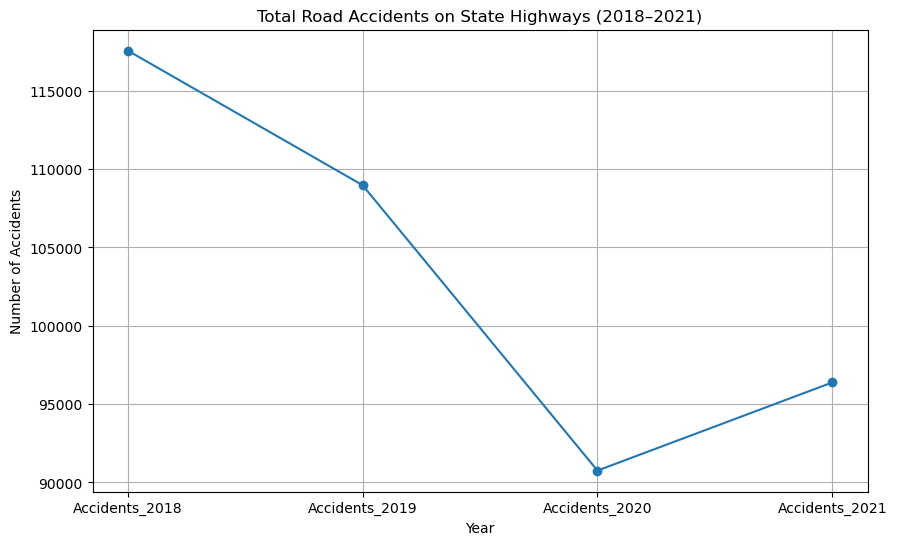

In [3]:
# Plotting temporal trend
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(yearly_totals.index, yearly_totals.values, marker='o')
plt.title('Total Road Accidents on State Highways (2018–2021)')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

#### Interpretation

- **Trend Visualization:** The line graph plots the total number of accidents from 2018 to 2021, with data points marked for each year.
- **2018–2019:** A gradual decline from ~117,570 to ~108,976, showing a steady decrease in accidents.
- **2019–2020:** A steep drop to ~90,755, reflecting the impact of reduced travel during the COVID-19 pandemic.
- **2020–2021:** A slight upward trend to ~96,382, indicating a recovery as normal activities resumed.
- **Overall Pattern:** The graph visually confirms a downward trend from 2018 to 2020, with a slight increase in 2021, highlighting the significant impact of 2020’s external factors.

#### Step 3: Regional Analysis

Identifying the top 5 states by 2021 accident counts and comparing their performance across years to spot consistent high-risk areas.


Top 5 States by Accidents in 2021:
          State_UT  Accidents_2018  Accidents_2019  Accidents_2020  \
22      Tamil Nadu         22849.0         19279.0         17213.0   
12  Madhya Pradesh         13910.0         13166.0         11751.0   
26   Uttar Pradesh         13788.0         13402.0         10555.0   
10       Karnataka         10685.0         10446.0          9465.0   
11          Kerala          7552.0          8097.0          5876.0   

    Accidents_2021  Rank_2021  
22         18656.0        1.0  
12         11475.0        2.0  
26         11096.0        3.0  
10          8820.0        4.0  
11          7290.0        5.0  


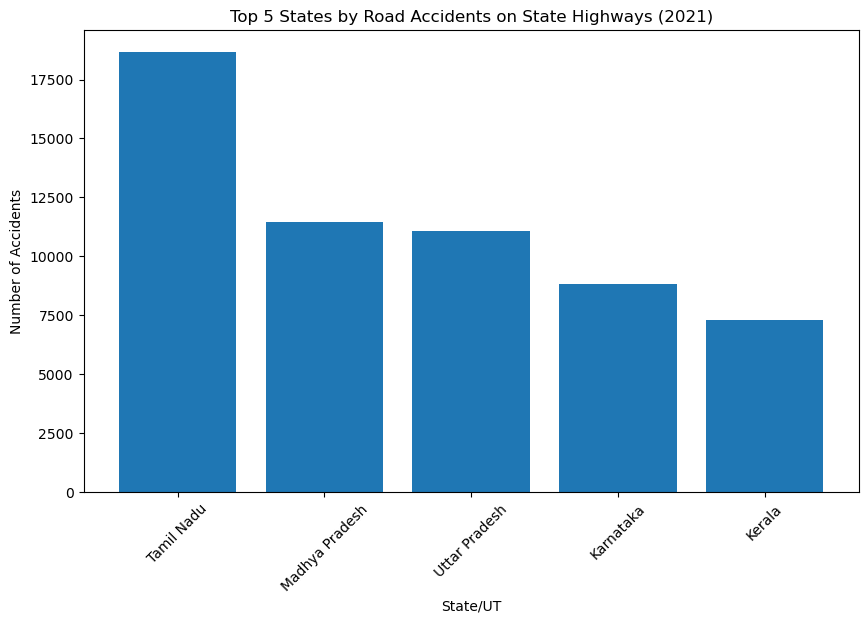

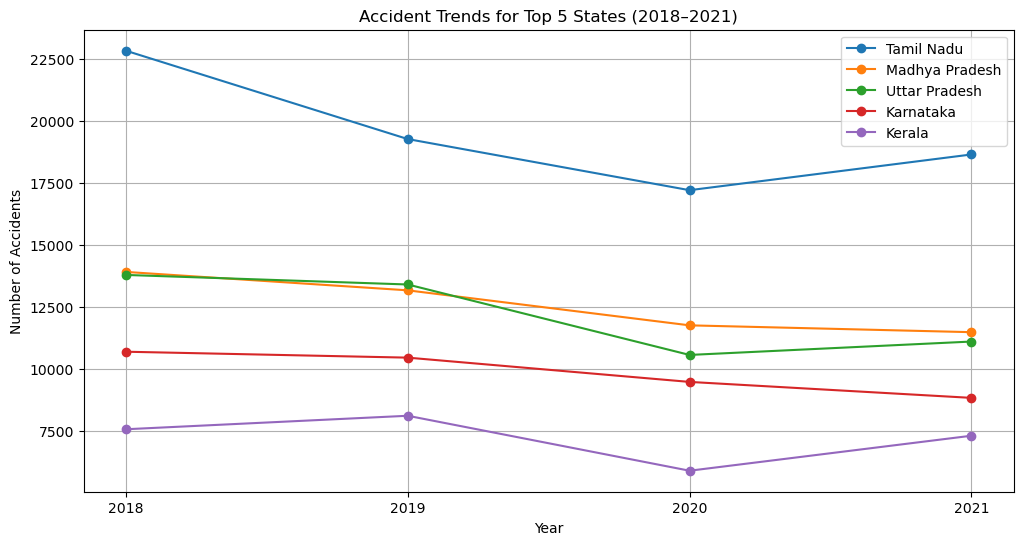

In [4]:
# Top 5 states in 2021
top_5_2021 = df.nlargest(5, 'Accidents_2021')[['State_UT', 'Accidents_2018', 'Accidents_2019', 'Accidents_2020', 'Accidents_2021', 'Rank_2021']]
print("\nTop 5 States by Accidents in 2021:")
print(top_5_2021)

# Bar chart for top 5 states in 2021
plt.figure(figsize=(10, 6))
plt.bar(top_5_2021['State_UT'], top_5_2021['Accidents_2021'])
plt.title('Top 5 States by Road Accidents on State Highways (2021)')
plt.xlabel('State/UT')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

# Trend for top 5 states over years
plt.figure(figsize=(12, 6))
for state in top_5_2021['State_UT']:
    state_data = df[df['State_UT'] == state][['Accidents_2018', 'Accidents_2019', 'Accidents_2020', 'Accidents_2021']].values.flatten()
    plt.plot(['2018', '2019', '2020', '2021'], state_data, marker='o', label=state)
plt.title('Accident Trends for Top 5 States (2018–2021)')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.legend()
plt.grid(True)
plt.show()

#### Interpretation

**Bar Chart: Top 5 States by Road Accidents on State Highways (2021)**

- **Distribution:** Tamil Nadu leads with ~ 18,656 accidents, followed by Madhya Pradesh (~ 11,475), Uttar Pradesh (~ 11,096), Karnataka (~ 8,820), and Kerala (~ 7,290).

- **Disparity:** Tamil Nadu’s accident count is significantly higher, nearly 1.5 times that of Madhya Pradesh, highlighting a major hotspot.

- **Regional Focus:** Southern states (Tamil Nadu, Karnataka, Kerala) dominate the top 5, indicating a regional concentration of accidents.

#### Interpretation

**Line Graph: Accident Trends for Top 5 States (2018–2021)**

- **Tamil Nadu:** Consistently highest, dropping from ~22,849 in 2018 to ~17,213 in 2020, then slightly rising to ~18,656 in 2021.
- **Madhya Pradesh & Uttar Pradesh:** Similar trends, declining from ~13,910 and ~13,788 in 2018 to ~11,751 and ~10,555 in 2020, with minor recovery in 2021.
- **Karnataka & Kerala:** Steady decline from 2018 to 2020 (e.g., Karnataka: 10,685 to 9,465), with a slight uptick in 2021, showing resilience post-2020.
- **Overall Pattern:** All states show a 2020 dip due to COVID-19, with varying degrees of recovery in 2021, Tamil Nadu remaining the most affected.

#### Step 4: Geospatial Visualization

Mapping accident counts across India using a choropleth map to highlight regional distribution. 

Note: This requires a GeoJSON file for Indian states, which we are using from a git repositroy.


GeoJSON State Column Names: Index(['STNAME', 'STCODE11', 'STNAME_SH', 'Shape_Length', 'Shape_Area',
       'OBJECTID_1', 'OBJECTID', 'State_LGD', 'Shape_Leng', 'MaxSimpTol',
       'MinSimpTol', 'geometry'],
      dtype='object')
Sample State Names in GeoJSON (STNAME): 0    ARUNACHAL PRADESH
1                ASSAM
2           CHANDIGARH
3         CHHATTISGARH
4                DELHI
Name: STNAME, dtype: object
Sample State Names in Dataset (State_UT): 0       Andhra Pradesh
1    Arunachal Pradesh
2                Assam
3                Bihar
4         Chhattisgarh
Name: State_UT, dtype: object
Unmatched States in GeoJSON (not in dataset): ['ANDAMAN & NICOBAR']
Unmatched States in Dataset (not in GeoJSON): ['ANDAMAN & NICOBAR ISLANDS']


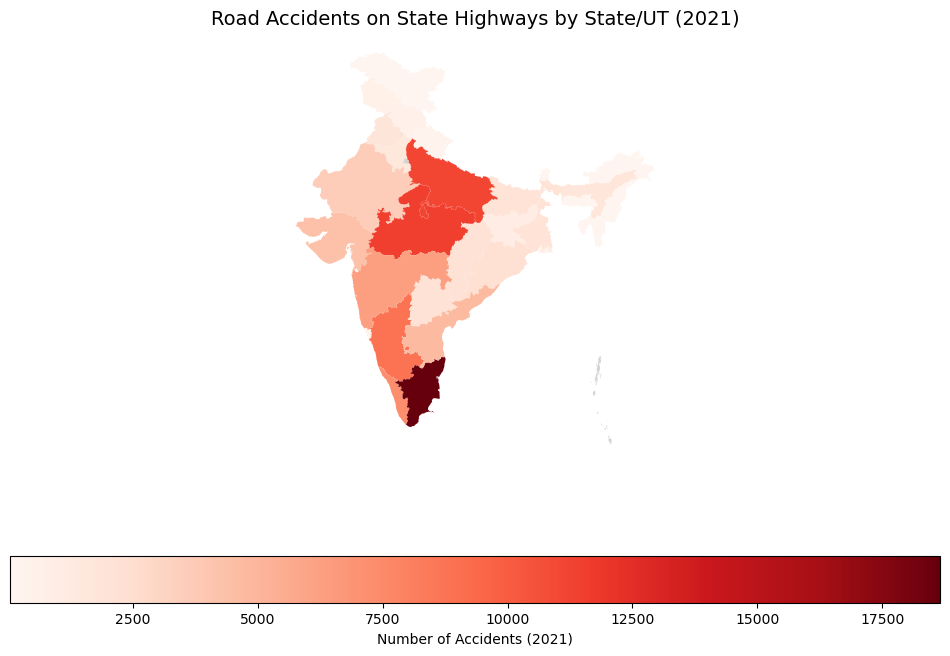

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Loading the GeoJSON file for Indian states (adjust the path if needed)
india_geo = gpd.read_file('INDIA_STATES.geojson')

# Inspecting the GeoJSON file's columns and state names
print("GeoJSON State Column Names:", india_geo.columns)
print("Sample State Names in GeoJSON (STNAME):", india_geo['STNAME'].head())  # Using 'STNAME' instead of 'name'

# Inspecting state names in the dataset for comparison
print("Sample State Names in Dataset (State_UT):", df['State_UT'].head())

# Standardizing state names to avoid mismatches (e.g., converting them to uppercase, replacing 'and' with '&')
india_geo['STNAME'] = india_geo['STNAME'].str.upper().str.replace(' AND ', ' & ')
df['State_UT'] = df['State_UT'].str.upper().str.replace(' AND ', ' & ')

# Merging the GeoJSON data with the accident dataset using the correct column
gdf = india_geo.merge(df, how='left', left_on='STNAME', right_on='State_UT')

# Checking for unmatched states
unmatched_geo = gdf[gdf['State_UT'].isna()]['STNAME'].unique()
print("Unmatched States in GeoJSON (not in dataset):", unmatched_geo)
unmatched_df = df[~df['State_UT'].isin(gdf['State_UT'])]['State_UT'].unique()
print("Unmatched States in Dataset (not in GeoJSON):", unmatched_df)

# Plotting the choropleth map for 2021 accidents
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(column='Accidents_2021', cmap='Reds', legend=True, ax=ax,
         missing_kwds={'color': 'lightgrey', 'label': 'Missing Data'},
         legend_kwds={'label': "Number of Accidents (2021)", 'orientation': "horizontal"})
plt.title('Road Accidents on State Highways by State/UT (2021)', fontsize=14)
ax.set_axis_off()  
plt.show()

#### Interpretation

- **Naming Mismatch:** "ANDAMAN & NICOBAR" is unmatched due to inconsistent naming between the GeoJSON and dataset.
- **High-Risk States:** Tamil Nadu, Madhya Pradesh, and Uttar Pradesh are the most accident-prone, with Tamil Nadu leading significantly.
- **Regional Hotspots:** Southern and central/northern India show higher accident rates, as indicated by darker shades on the map.
- **Data Gaps:** Missing data for Andaman & Nicobar Islands highlights the need for name standardization.

## Results

**1.Temporal Trends:**
- Accidents decreased from 117,570 in 2018 to 90,755 in 2020 (likely due to COVID-19 restrictions), then rose to 96,382 in 2021.
- The 2020 drop (~ 23% from 2019) and 2021 recovery (~ 6% increase) suggest external factors like mobility restrictions impacted accident rates.

**2.Regional Patterns:**
- Tamil Nadu (18,656), Madhya Pradesh (11,475), and Uttar Pradesh (11,096) consistently rank highest in 2021, indicating persistent high-risk zones.
- Smaller states/UTs (e.g., Mizoram, Lakshadweep) report near-zero accidents, possibly due to fewer highways or underreporting.

**3.Visual Insights:**
- Bar charts confirm Tamil Nadu’s dominance in 2021.
- Line plots show a general decline across top states in 2020, with varying recovery in 2021.
- The geospatial map highlight southern and central India as accident hotspots.

## Conclusion

This EDA reveals a significant decline in state highway accidents during 2020, followed by a partial rebound in 2021, likely tied to pandemic-related mobility changes. Tamil Nadu, Madhya Pradesh, and Uttar Pradesh emerge as priority regions for safety interventions due to their high and consistent accident counts. While the dataset limits analysis to frequency and location, these insights can guide resource allocation (e.g., increased patrols, infrastructure upgrades) in high-risk areas.